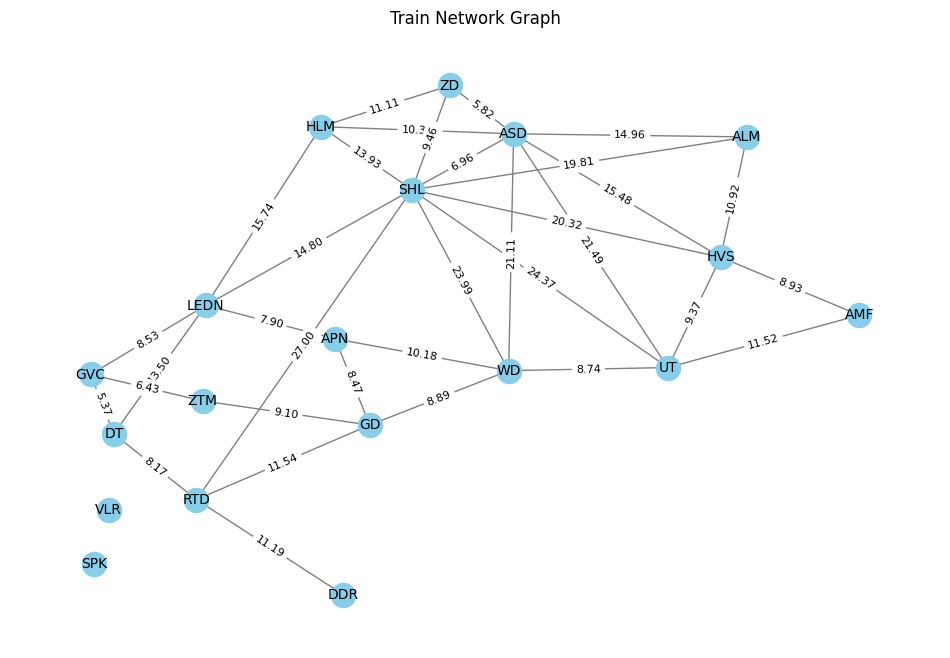

In [17]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm 
import matplotlib.colors as mcolors
import numpy as np
from itertools import combinations


# Note: all nodes (so car network) but train network

# Load CSVs
nodes_df = pd.read_csv(f"network_nodes_car.csv")  # columns: name, station, lat, lng
edges_df = pd.read_csv(f"network_edges_train.csv")  # columns: from, to, travel_time

# Create undirected graph
G_red = nx.Graph()

# Add nodes with attributes
for _, row in nodes_df.iterrows():
    G_red.add_node(row['name'], lat=row['lat'], lon=row['lng'], station=row['station'])

# Add edges from CSV
for _, row in edges_df.iterrows():
    G_red.add_edge(row['from'], row['to'], weight=row['travel_time'])

# Positions based on lon/x and lat/y
pos = {node: (data['lon'], data['lat']) for node, data in G_red.nodes(data=True)}

# Plot the graph
plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G_red, pos, node_size=300, node_color='skyblue')
nx.draw_networkx_edges(G_red, pos, edge_color='gray')  # undirected, no arrows
nx.draw_networkx_labels(G_red, pos, font_size=10, font_color='black')

# Edge labels = travel_time rounded to 2 decimals
edge_labels = { (u,v): f"{d['weight']:.2f}" for u,v,d in G_red.edges(data=True) }
nx.draw_networkx_edge_labels(G_red, pos, edge_labels=edge_labels, font_size=8)

plt.title(f"Train Network Graph")
plt.axis('off')
plt.show()

In [18]:
pop_df     = pd.read_csv("population_sizes.csv")
pop_lookup = dict(zip(pop_df["name"], pop_df["population"]))

# Build new graph from G_red with importance as edge weight
# importance(i, j) = (pop_i * pop_j) / travel_time²
G_pop = nx.Graph()

for node, data in G_red.nodes(data=True):
    G_pop.add_node(node, **data, population=pop_lookup.get(node, 0))

for u, v, data in G_red.edges(data=True):
    pop_u = pop_lookup.get(u, 0)
    pop_v = pop_lookup.get(v, 0)
    tt    = data["weight"]  # travel_time

    importance = (pop_u * pop_v) / (tt ** 2)

    G_pop.add_edge(u, v, weight=importance, travel_time=tt, importance=importance)

print(f"G_pop: {G_pop.number_of_nodes()} nodes, {G_pop.number_of_edges()} edges")

G_pop: 19 nodes, 34 edges


In [19]:
rows = []
for u, v, d in G_pop.edges(data=True):
    rows.append({
        "from":        u,
        "to":          v,
        "pop_from":    pop_lookup.get(u, 0),
        "pop_to":      pop_lookup.get(v, 0),
        "travel_time": round(d["travel_time"], 2),
        "importance":  round(d["importance"], 2)
    })

importance_df = (
    pd.DataFrame(rows)
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
print(importance_df.to_string(index=False))

from   to  pop_from  pop_to  travel_time   importance
 ASD  SHL    942504  140000         6.96 2.725857e+09
 ASD   ZD    942504   82410         5.82 2.289753e+09
  DT  GVC    110044  569076         5.37 2.170144e+09
 GVC  ZTM    569076  130850         6.43 1.798370e+09
 ASD  HLM    942504  168946        10.30 1.500774e+09
  DT  RTD    110044  674500         8.17 1.110658e+09
 GVC LEDN    569076  130298         8.53 1.017971e+09
 ALM  ASD    232650  942504        14.96 9.800484e+08
 ASD   UT    942504  378140        21.49 7.715187e+08
 DDR  RTD    122933  674500        11.19 6.620951e+08
 AMF   UT    163766  378140        11.52 4.670263e+08
 HVS   UT     94601  378140         9.37 4.071563e+08
  GD  RTD     77803  674500        11.54 3.942106e+08
 ASD  HVS    942504   94601        15.48 3.722594e+08
  UT   WD    378140   54208         8.74 2.682777e+08
 APN LEDN    117278  130298         7.90 2.448550e+08
 AMF  HVS    163766   94601         8.93 1.940760e+08
 ALM  HVS    232650   94601 

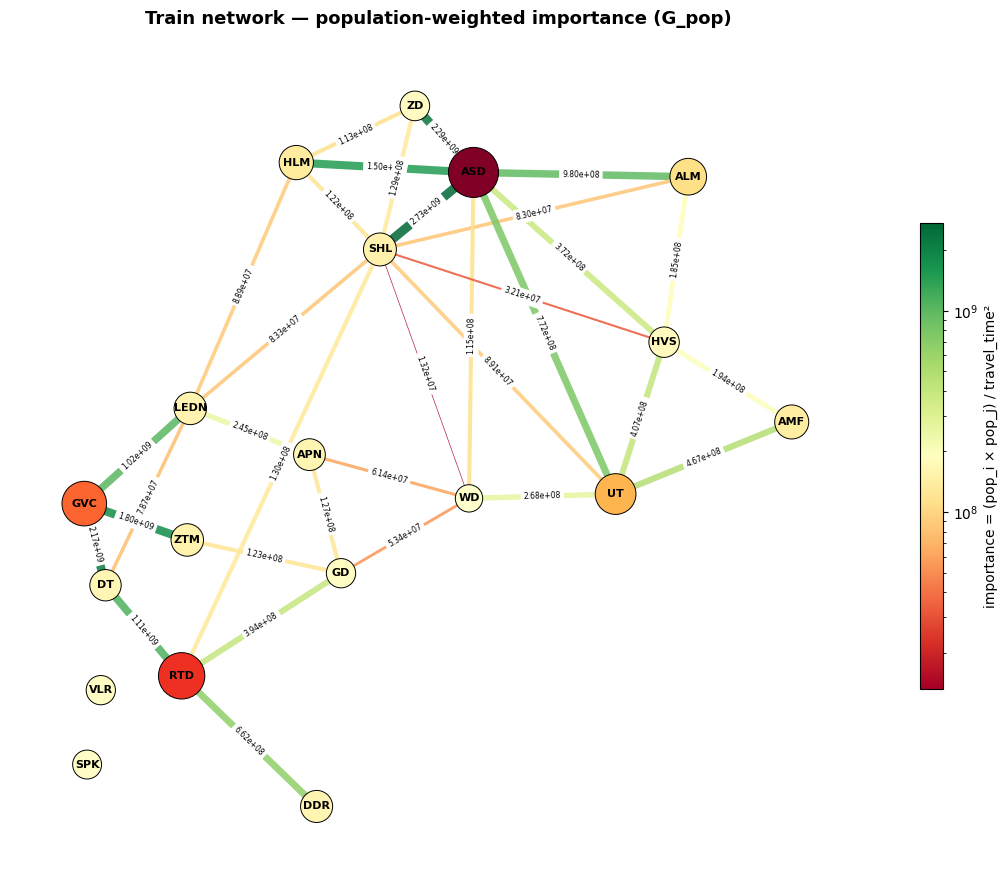

In [20]:
fig, ax = plt.subplots(figsize=(11, 9))

pops  = np.array([G_pop.nodes[n]["population"] for n in G_pop.nodes()])
sizes = 100 + 1200 * (np.sqrt(pops) / np.sqrt(pops.max()))

importances = np.array([d["importance"] for _, _, d in G_pop.edges(data=True)])
norm        = mcolors.LogNorm(vmin=importances.min(), vmax=importances.max())
cmap        = cm.RdYlGn
edge_colors = [cmap(norm(v)) for v in importances]
edge_widths = [0.5 + 6.0 * norm(v) for v in importances]

nx.draw_networkx_edges(G_pop, pos, ax=ax,
                       edge_color=edge_colors, width=edge_widths, alpha=0.85)
nx.draw_networkx_nodes(G_pop, pos, ax=ax,
                       node_size=list(sizes),
                       node_color=list(pops),
                       cmap=cm.YlOrRd,
                       edgecolors="black", linewidths=0.7)
nx.draw_networkx_labels(G_pop, pos, ax=ax, font_size=8, font_weight="bold")

edge_labels = {(u, v): f"{d['importance']:.2e}" for u, v, d in G_pop.edges(data=True)}
nx.draw_networkx_edge_labels(G_pop, pos, edge_labels=edge_labels, font_size=5.5, ax=ax)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.55,
             label="importance = (pop_i × pop_j) / travel_time²")

ax.set_title("Train network — population-weighted importance (G_pop)", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

In [21]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    lon1 = np.radians(lon1)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [22]:
def calculate_travel_time(G, node1, node2, km_to_time=0.572):
    lat1 = G.nodes[node1]['lat']
    lon1 = G.nodes[node1]['lon']
    lat2 = G.nodes[node2]['lat']
    lon2 = G.nodes[node2]['lon']
    
    distance_km = haversine(lat1, lon1, lat2, lon2)
    travel_time = distance_km * km_to_time
    return travel_time

In [23]:
def evaluate_all_possible_new_edges(G, km_to_time=0.572):
    candidates = []

    for node1, node2 in combinations(G.nodes(), 2):
        if G.has_edge(node1, node2):
            continue

        travel_time = calculate_travel_time(G, node1, node2, km_to_time=km_to_time)

        pop1 = G.nodes[node1].get("population", 0)
        pop2 = G.nodes[node2].get("population", 0)

        importance = (pop1 * pop2) / (travel_time ** 2) if travel_time > 0 else 0

        candidates.append({
            "from_node": node1,
            "to_node": node2,
            "travel_time": travel_time,
            "importance": importance
        })

    return candidates

In [24]:
all_candidates = evaluate_all_possible_new_edges(G_pop)

print(f"Number of possible new single-edge additions: {len(all_candidates)}")
print("Example candidate edges:")

# Example: inspect first few candidates
for c in all_candidates[:5]:
    print(
        c["from_node"], "->", c["to_node"],
        "| travel_time =", round(c["travel_time"], 2),
        "| importance =", round(c["importance"], 2)
    )

Number of possible new single-edge additions: 137
Example candidate edges:
ALM -> APN | travel_time = 27.01 | importance = 37412737.38
ALM -> AMF | travel_time = 15.27 | importance = 163333662.83
ALM -> DT | travel_time = 40.95 | importance = 15270252.15
ALM -> GVC | travel_time = 39.51 | importance = 84824684.08
ALM -> DDR | travel_time = 42.01 | importance = 16203837.68


In [25]:
def evaluate_network_metrics_pop(network):
    for u, v, d in network.edges(data=True):
        network[u][v]['distance'] = 1 / d['importance']

    dcn         = nx.degree_centrality(network)
    ccn         = nx.closeness_centrality(network, distance='distance')
    bcn         = nx.betweenness_centrality(network, weight='distance', normalized=True)
    lcn         = nx.clustering(network, weight='weight')
    eigenvector = nx.eigenvector_centrality(network, weight='weight', max_iter=1000)

    metrics_df = pd.DataFrame({
        'Node':       list(network.nodes()),
        'Station':    [network.nodes[n]['station']    for n in network.nodes()],
        'Population': [network.nodes[n]['population'] for n in network.nodes()],
        'DCN':  [dcn[n]         for n in network.nodes()],
        'CCN':  [ccn[n]         for n in network.nodes()],
        'BCN':  [bcn[n]         for n in network.nodes()],
        'LCN':  [lcn[n]         for n in network.nodes()],
        'EC':   [eigenvector[n] for n in network.nodes()],
    })

    # Min-max normalise each metric to [0, 1]
    metric_cols = ['DCN', 'CCN', 'BCN', 'LCN', 'EC']
    for col in metric_cols:
        col_min = metrics_df[col].min()
        col_max = metrics_df[col].max()
        if col_max > col_min:  # avoid division by zero if all values are equal
            metrics_df[col] = (metrics_df[col] - col_min) / (col_max - col_min)

    metrics_df = metrics_df.round(4)
    return metrics_df.sort_values('DCN', ascending=False).reset_index(drop=True)


In [26]:
hub_locations = ['SHL', 'UT', 'ASD']
metric_names = ['DCN', 'CCN', 'BCN', 'LCN', 'EC']

metrics_original = evaluate_network_metrics_pop(G_pop)
metrics_original_hub = metrics_original[metrics_original['Node'].isin(hub_locations)]

print("Original Network Metrics:")
print(metrics_original_hub)

Original Network Metrics:
  Node             Station  Population     DCN     CCN     BCN     LCN      EC
0  SHL    Schiphol Airport      140000  1.0000  1.0000  0.8182  0.1802  0.6852
1  ASD  Amsterdam Centraal      942504  0.7778  0.9962  1.0000  0.4246  1.0000
3   UT    Utrecht Centraal      378140  0.5556  0.8802  0.3636  0.3125  0.2150


In [27]:
# Store best result per hub per metric, plus total
best_links = {
    hub: {
        metric: {"score": float("-inf"), "candidate": None, "delta": None}
        for metric in metric_names + ['SUM']
    }
    for hub in hub_locations
}

In [28]:
for c in all_candidates:
    G_test = G_pop.copy()
    G_test.add_edge(
        c["from_node"],
        c["to_node"],
        weight=c["importance"],
        travel_time=c["travel_time"],
        importance=c["importance"]
    )

    metrics = evaluate_network_metrics_pop(G_test)
    metrics_hub = metrics[metrics['Node'].isin(hub_locations)]

    delta_metrics = (
        metrics_hub.set_index('Node')[metric_names]
        - metrics_original_hub.set_index('Node')[metric_names]
    )

    for hub in hub_locations:
        delta = delta_metrics.loc[hub]

        # Best per individual metric
        for metric in metric_names:
            score = delta[metric]

            if score > best_links[hub][metric]["score"]:
                best_links[hub][metric] = {
                    "score": score,
                    "candidate": c,
                    "delta": delta.copy()
                }

        # Best by sum of all metrics
        sum_score = delta.sum()

        if sum_score > best_links[hub]['SUM']["score"]:
            best_links[hub]['SUM'] = {
                "score": sum_score,
                "candidate": c,
                "delta": delta.copy()
            }

In [33]:
result_names = ['SUM']
for hub in hub_locations:
    print(f"\n=== {hub} ===")
    for metric in result_names:
        result = best_links[hub][metric]
        candidate = result["candidate"]

        print(f"\nBest for {metric}:")
        print(f"  Score: {result['score']:.4f}")
        print(f"  Link: {candidate['from_node']} - {candidate['to_node']}")
        print(f"  Travel time: {candidate['travel_time']:.2f}")
        print(f"  Importance: {candidate['importance']:.2f}")
        print(f"  Delta metrics:\n{result['delta']}")


=== SHL ===

Best for SUM:
  Score: 0.1209
  Link: RTD - ZD
  Travel time: 35.34
  Importance: 44502359.55
  Delta metrics:
DCN    0.0000
CCN    0.0000
BCN    0.0000
LCN    0.1208
EC     0.0001
Name: SHL, dtype: float64

=== UT ===

Best for SUM:
  Score: 0.7847
  Link: RTD - UT
  Travel time: 27.19
  Importance: 345017352.18
  Delta metrics:
DCN    0.1111
CCN    0.1198
BCN    0.6364
LCN   -0.0864
EC     0.0038
Name: UT, dtype: float64

=== ASD ===

Best for SUM:
  Score: 0.3021
  Link: HVS - ZD
  Travel time: 19.71
  Importance: 20063242.03
  Delta metrics:
DCN    0.0000
CCN    0.0000
BCN    0.0000
LCN    0.3021
EC     0.0000
Name: ASD, dtype: float64


In [30]:
len(all_candidates)

137

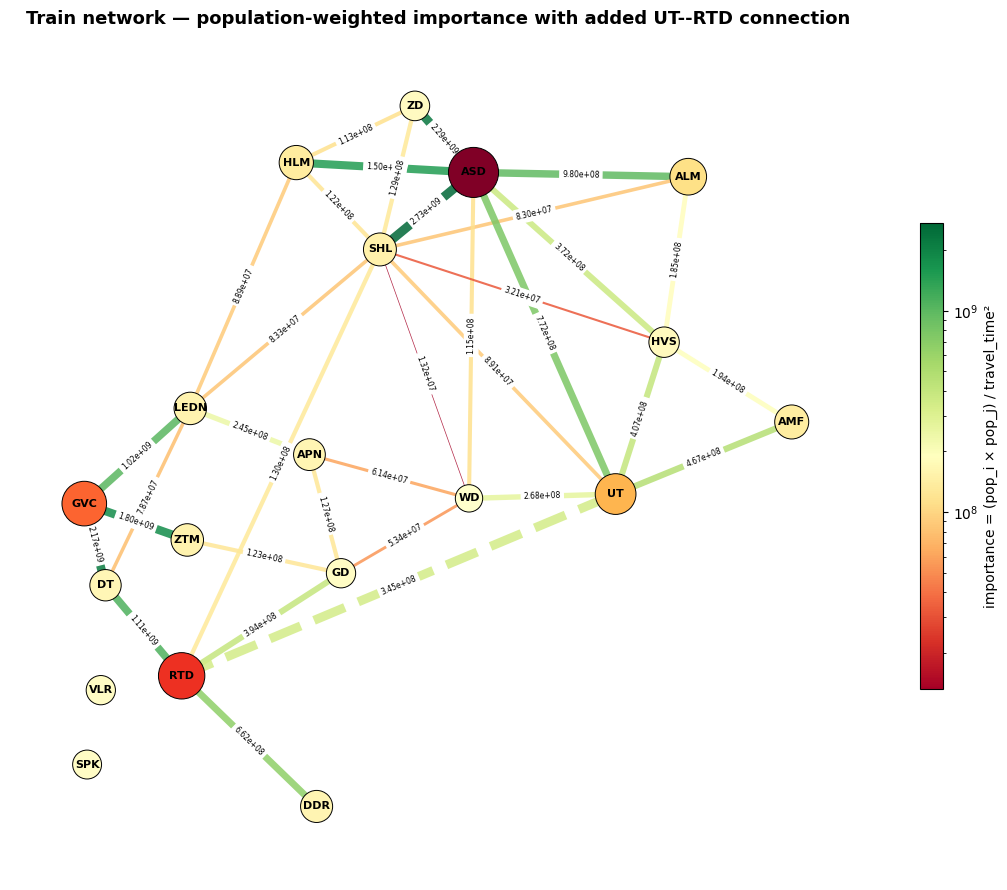

In [37]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
import networkx as nx
import numpy as np

# Create a copy and add the new connection
G_pop_ut_rtd = G_pop.copy()

travel_time_ut_rtd = 27.19

pop_ut = G_pop_ut_rtd.nodes["UT"]["population"]
pop_rtd = G_pop_ut_rtd.nodes["RTD"]["population"]
importance_ut_rtd = (pop_ut * pop_rtd) / (travel_time_ut_rtd ** 2)

G_pop_ut_rtd.add_edge(
    "UT",
    "RTD",
    weight=travel_time_ut_rtd,
    importance=importance_ut_rtd
)

fig, ax = plt.subplots(figsize=(11, 9))

pops = np.array([G_pop_ut_rtd.nodes[n]["population"] for n in G_pop_ut_rtd.nodes()])
sizes = 100 + 1200 * (np.sqrt(pops) / np.sqrt(pops.max()))

importances = np.array([d["importance"] for _, _, d in G_pop_ut_rtd.edges(data=True)])
norm = mcolors.LogNorm(vmin=importances.min(), vmax=importances.max())
cmap = cm.RdYlGn

edge_colors = []
edge_widths = []
edge_styles = []

for u, v, d in G_pop_ut_rtd.edges(data=True):
    edge_colors.append(cmap(norm(d["importance"])))
    if {u, v} == {"UT", "RTD"}:
        edge_widths.append(6.5)
        edge_styles.append("dashed")
    else:
        edge_widths.append(0.5 + 6.0 * norm(d["importance"]))
        edge_styles.append("solid")

# Draw edges separately per style
edges_list = list(G_pop_ut_rtd.edges())

for style in ["solid", "dashed"]:
    edgelist = [
        edge for edge, s in zip(edges_list, edge_styles) if s == style
    ]
    widths = [
        w for w, s in zip(edge_widths, edge_styles) if s == style
    ]
    colors = [
        c for c, s in zip(edge_colors, edge_styles) if s == style
    ]

    nx.draw_networkx_edges(
        G_pop_ut_rtd,
        pos,
        ax=ax,
        edgelist=edgelist,
        edge_color=colors,
        width=widths,
        style=style,
        alpha=0.85
    )

nx.draw_networkx_nodes(
    G_pop_ut_rtd,
    pos,
    ax=ax,
    node_size=list(sizes),
    node_color=list(pops),
    cmap=cm.YlOrRd,
    edgecolors="black",
    linewidths=0.7
)

nx.draw_networkx_labels(
    G_pop_ut_rtd,
    pos,
    ax=ax,
    font_size=8,
    font_weight="bold"
)

edge_labels = {
    (u, v): f"{d['importance']:.2e}"
    for u, v, d in G_pop_ut_rtd.edges(data=True)
}
nx.draw_networkx_edge_labels(
    G_pop_ut_rtd,
    pos,
    edge_labels=edge_labels,
    font_size=5.5,
    ax=ax
)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(
    sm,
    ax=ax,
    shrink=0.55,
    label="importance = (pop_i × pop_j) / travel_time²"
)

ax.set_title(
    "Train network — population-weighted importance with added UT--RTD connection",
    fontsize=13,
    fontweight="bold"
)
ax.axis("off")
plt.tight_layout()
plt.savefig("part4_network.png")
plt.show()
